# 1. Data Loading and Initial Inspection

The dataset is loaded and inspected to understand its structure, data types, and missing values. 
A copy of the selected columns is created so the original raw dataset remains unchanged.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Load the raw dataset
raw_df = pd.read_csv("data/raw/FullData.csv")

# Keep only required columns
df = raw_df[
    [
        "Name",
        "Nationality",
        "National_Position",
        "Club",
        "Club_Position",
        "Rating",
        "Height",
        "Weight",
        "Birth_Date",
        "Age",
        "Skill_Moves",
        "Ball_Control",
        "Dribbling",
        "Speed",
        "Strength"
    ]
].copy()

# Preview
df.head()

,Name,Nationality,National_Position,Club,Club_Position,Rating,Height,Weight,Birth_Date,Age,Skill_Moves,Ball_Control,Dribbling,Speed,Strength
0,Cristiano Ronaldo,Portugal,LS,Real Madrid,LW,94,185 cm,80 kg,02/05/1985,32,5,93,92,92,80
1,Lionel Messi,Argentina,RW,FC Barcelona,RW,93,170 cm,72 kg,06/24/1987,29,4,95,97,87,59
2,Neymar,Brazil,LW,FC Barcelona,LW,92,174 cm,68 kg,02/05/1992,25,5,95,96,90,49
3,Luis Suárez,Uruguay,LS,FC Barcelona,ST,92,182 cm,85 kg,01/24/1987,30,4,91,86,77,76
4,Manuel Neuer,Germany,GK,FC Bayern,GK,92,193 cm,92 kg,03/27/1986,31,1,48,30,61,83


In [43]:
# Check the shape of the dataset
df.shape

(17588, 15)

In [44]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17588 entries, 0 to 17587
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Name               17588 non-null  str  
 1   Nationality        17588 non-null  str  
 2   National_Position  1075 non-null   str  
 3   Club               17588 non-null  str  
 4   Club_Position      17587 non-null  str  
 5   Rating             17588 non-null  int64
 6   Height             17588 non-null  str  
 7   Weight             17588 non-null  str  
 8   Birth_Date         17588 non-null  str  
 9   Age                17588 non-null  int64
 10  Skill_Moves        17588 non-null  int64
 11  Ball_Control       17588 non-null  int64
 12  Dribbling          17588 non-null  int64
 13  Speed              17588 non-null  int64
 14  Strength           17588 non-null  int64
dtypes: int64(7), str(8)
memory usage: 2.0 MB


In [45]:
# Statistical summary of numerical columns
df.describe()

,Rating,Age,Skill_Moves,Ball_Control,Dribbling,Speed,Strength
count,17588.000000,17588.000000,17588.000000,17588.000000,17588.000000,17588.000000,17588.000000
mean,66.166193,25.460314,2.303161,57.972766,54.802877,65.483853,65.085854
std,7.083012,4.680217,0.746156,16.834779,18.913857,14.100615,12.532989
min,45.000000,17.000000,1.000000,5.000000,4.000000,11.000000,20.000000
25%,62.000000,22.000000,2.000000,53.000000,47.000000,58.000000,57.000000
50%,66.000000,25.000000,2.000000,63.000000,60.000000,68.000000,66.000000
75%,71.000000,29.000000,3.000000,69.000000,68.000000,75.000000,74.000000
max,94.000000,47.000000,5.000000,95.000000,97.000000,96.000000,98.000000


In [46]:
# Check for missing values
df.isnull().sum()

Name                     0
Nationality              0
National_Position    16513
Club                     0
Club_Position            1
Rating                   0
Height                   0
Weight                   0
Birth_Date               0
Age                      0
Skill_Moves              0
Ball_Control             0
Dribbling                0
Speed                    0
Strength                 0
dtype: int64

In [47]:
# Series example
example_series = pd.Series([1, 2, 3])
example_series

0    1
1    2
2    3
dtype: int64

In [48]:
# DataFrame example
example_df = pd.DataFrame({
    "A": [1, 2],
    "B": [3, 4]
})
example_df

,A,B
0,1,3
1,2,4


In [49]:
# iloc example
df.iloc[0:5, 0:5]

,Name,Nationality,National_Position,Club,Club_Position
0,Cristiano Ronaldo,Portugal,LS,Real Madrid,LW
1,Lionel Messi,Argentina,RW,FC Barcelona,RW
2,Neymar,Brazil,LW,FC Barcelona,LW
3,Luis Suárez,Uruguay,LS,FC Barcelona,ST
4,Manuel Neuer,Germany,GK,FC Bayern,GK


In [50]:
# loc example
df.loc[df['Rating'] > 85, ['Name', 'Club', 'Rating']].head()

,Name,Club,Rating
0,Cristiano Ronaldo,Real Madrid,94
1,Lionel Messi,FC Barcelona,93
2,Neymar,FC Barcelona,92
3,Luis Suárez,FC Barcelona,92
4,Manuel Neuer,FC Bayern,92


In [51]:
# boolean filtering
df[df["Rating"] >= 85].head()

,Name,Nationality,National_Position,Club,Club_Position,Rating,Height,Weight,Birth_Date,Age,Skill_Moves,Ball_Control,Dribbling,Speed,Strength
0,Cristiano Ronaldo,Portugal,LS,Real Madrid,LW,94,185 cm,80 kg,02/05/1985,32,5,93,92,92,80
1,Lionel Messi,Argentina,RW,FC Barcelona,RW,93,170 cm,72 kg,06/24/1987,29,4,95,97,87,59
2,Neymar,Brazil,LW,FC Barcelona,LW,92,174 cm,68 kg,02/05/1992,25,5,95,96,90,49
3,Luis Suárez,Uruguay,LS,FC Barcelona,ST,92,182 cm,85 kg,01/24/1987,30,4,91,86,77,76
4,Manuel Neuer,Germany,GK,FC Bayern,GK,92,193 cm,92 kg,03/27/1986,31,1,48,30,61,83


# 2. Cleaning and Transformation
The dataset is cleaned by removing duplicate records, handling missing values, converting data types, and transforming height and weight into more interpretable units. A new feature is also created to categorize player performance levels.

Duplicate names are not removed by name alone because the same player name may appear across different clubs. Instead, duplicates will be checked and removed using both Name and Club.

In [52]:
# Check true duplicates using Name + Club
df.duplicated(subset=["Name", "Club"]).sum()

np.int64(4)

In [53]:
# Remove true duplicate player-club records
df = df.drop_duplicates(subset=["Name", "Club"])

In [54]:
# Confirm duplicates were removed
df.duplicated(subset=["Name", "Club"]).sum()

np.int64(0)

In [55]:
# Fill missing national positions with "Unknown"
# These are not removed because many players do not have a national team position
df["National_Position"] = df["National_Position"].fillna("Unknown")

In [56]:
# Remove rows with missing club positions
df = df.dropna(subset=["Club_Position"])

In [57]:
# Convert birth date to datetime
df["Birth_Date"] = pd.to_datetime(df["Birth_Date"], errors="coerce")

In [58]:
# Convert selected columns to numeric
numeric_cols = [
    "Rating",
    "Age",
    "Skill_Moves",
    "Ball_Control",
    "Dribbling",
    "Speed",
    "Strength"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Height and weight were originally recorded in centimeters and kilograms. They were converted to inches and pounds to make the data more interpretable.

In [59]:
# Clean Height: convert from strings like "185 cm" to inches
df["Height"] = df["Height"].astype(str).str.replace(" cm", "", regex=False).str.strip()
df["Height"] = pd.to_numeric(df["Height"], errors="coerce")
df["Height"] = (df["Height"] / 2.54).round(2)

In [60]:
# Clean Weight: convert from strings like "80 kg" to pounds
df["Weight"] = df["Weight"].astype(str).str.replace(" kg", "", regex=False).str.strip()
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")
df["Weight"] = (df["Weight"] * 2.20462).round(2)

In [61]:
df[["Height", "Weight"]].head()

,Height,Weight
0,72.83,176.37
1,66.93,158.73
2,68.50,149.91
3,71.65,187.39
4,75.98,202.83


In [62]:
# Check missing values again after conversions
df.isnull().sum()

Name                 0
Nationality          0
National_Position    0
Club                 0
Club_Position        0
Rating               0
Height               0
Weight               0
Birth_Date           0
Age                  0
Skill_Moves          0
Ball_Control         0
Dribbling            0
Speed                0
Strength             0
dtype: int64

In [63]:
# Create a new column using np.where
df["Player_Level"] = np.where(
    df["Rating"] >= 80,
    "Elite",
    np.where(df["Rating"] >= 70, "Average", "Below Average")
)

Converting a few repeated text columns to the `category` dtype helps make the cleaned dataset more consistent and memory-efficient.

In [64]:
# Optional categorical conversion
categorical_cols = ["Nationality", "National_Position", "Club", "Club_Position", "Player_Level"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

df.dtypes

Name                            str
Nationality                category
National_Position          category
Club                       category
Club_Position              category
Rating                        int64
Height                      float64
Weight                      float64
Birth_Date           datetime64[us]
Age                           int64
Skill_Moves                   int64
Ball_Control                  int64
Dribbling                     int64
Speed                         int64
Strength                      int64
Player_Level               category
dtype: object

In [65]:
# Grouping and multi-column aggregation
position_summary = (
    df.groupby("Club_Position")
      .agg(
          player_count=("Name", "count"),
          avg_rating=("Rating", "mean"),
          median_rating=("Rating", "median"),
          avg_speed=("Speed", "mean"),
          avg_strength=("Strength", "mean")
      )
      .sort_values("avg_rating", ascending=False)
)

position_summary.head(10)

,player_count,avg_rating,median_rating,avg_speed,avg_strength
Club_Position,,,,,
RF,12,72.000000,70.5,72.500000,60.250000
LW,133,71.842105,72.0,80.097744,60.045113
ST,426,71.269953,71.0,72.157277,73.915493
LAM,36,71.250000,72.0,74.305556,57.222222
RAM,36,71.222222,71.0,73.388889,59.611111
LF,12,71.083333,71.5,72.333333,60.416667
RW,133,70.939850,70.0,79.353383,60.030075
CDM,119,70.848739,70.0,61.613445,71.571429
CAM,315,70.590476,70.0,70.425397,60.828571


In [66]:
# Simple reshaping with pivot_table
rating_pivot = pd.pivot_table(
    df,
    values="Rating",
    index="Club_Position",
    columns="Player_Level",
    aggfunc="mean"
)

rating_pivot.head(10)

Player_Level,Average,Below Average,Elite
Club_Position,,,
CAM,73.521212,65.462687,83.312500
CB,73.031250,64.755556,83.166667
CDM,73.421053,65.200000,82.166667
CF,70.000000,66.000000,NaN
CM,73.352941,64.833333,82.333333
GK,73.517241,64.616352,82.905660
LAM,73.421053,66.142857,81.333333
LB,73.287879,64.480712,82.000000
LCB,73.101887,64.727545,82.875000


In [67]:
# Save the cleaned dataset
df.to_csv("data/processed/cleaned_players.csv", index=False)

In [68]:
# Final check of data types and missing values
df.info()

<class 'pandas.DataFrame'>
Index: 17583 entries, 0 to 17587
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               17583 non-null  str           
 1   Nationality        17583 non-null  category      
 2   National_Position  17583 non-null  category      
 3   Club               17583 non-null  category      
 4   Club_Position      17583 non-null  category      
 5   Rating             17583 non-null  int64         
 6   Height             17583 non-null  float64       
 7   Weight             17583 non-null  float64       
 8   Birth_Date         17583 non-null  datetime64[us]
 9   Age                17583 non-null  int64         
 10  Skill_Moves        17583 non-null  int64         
 11  Ball_Control       17583 non-null  int64         
 12  Dribbling          17583 non-null  int64         
 13  Speed              17583 non-null  int64         
 14  Strength           175

In [69]:
df.isnull().sum()

Name                 0
Nationality          0
National_Position    0
Club                 0
Club_Position        0
Rating               0
Height               0
Weight               0
Birth_Date           0
Age                  0
Skill_Moves          0
Ball_Control         0
Dribbling            0
Speed                0
Strength             0
Player_Level         0
dtype: int64

## 3. Exploratory Data Analysis

This section explores the cleaned FIFA dataset using descriptive statistics and basic exploratory data analysis. The goal is to better understand the structure of the data, summarize important numeric features, examine categorical variables, and identify patterns in player ratings.

In [70]:
# Summary statistics of the cleaned dataset
print("Mean Rating:", df["Rating"].mean())
print("Median Rating:", df["Rating"].median())
print("Minimum Rating:", df["Rating"].min())
print("Maximum Rating:", df["Rating"].max())
print("Standard Deviation:", df["Rating"].std())


Mean Rating: 66.16606949894785
Median Rating: 66.0
Minimum Rating: 45
Maximum Rating: 94
Standard Deviation: 7.082717622782528


In [71]:
# Summary stats for multiple numeric columns
df[["Rating", "Age", "Speed", "Strength"]].describe()

,Rating,Age,Speed,Strength
count,17583.000000,17583.000000,17583.000000,17583.000000
mean,66.166069,25.460047,65.487403,65.083717
std,7.082718,4.679366,14.099055,12.531700
min,45.000000,17.000000,11.000000,20.000000
25%,62.000000,22.000000,58.000000,57.000000
50%,66.000000,25.000000,68.000000,66.000000
75%,71.000000,29.000000,75.000000,74.000000
max,94.000000,47.000000,96.000000,98.000000


In [72]:
# Grouped statistics by Player_Level
player_level_stats = df.groupby("Player_Level")["Rating"].describe()
player_level_stats

,count,mean,std,min,25%,50%,75%,max
Player_Level,,,,,,,,
Average,5017.0,73.178393,2.594058,70.0,71.0,73.0,75.0,79.0
Below Average,12038.0,62.532647,4.996690,45.0,59.0,64.0,67.0,69.0
Elite,528.0,82.375000,2.530928,80.0,80.0,82.0,83.0,94.0


By grouping players based on their position, we can identify whether certain roles (such as forwards or defenders) tend to have higher average ratings. This provides insight into how player responsibilities and roles may influence overall performance

In [73]:
def categorize_position(pos):
    if pos in ["ST", "CF", "LW", "RW"]:
        return "Forward"
    elif pos in ["CM", "CDM", "CAM"]:
        return "Midfielder"
    elif pos in ["CB", "LB", "RB"]:
        return "Defender"
    elif pos == "GK":
        return "Goalkeeper"
    else:
        return "Other"

df["Position_Group"] = df["Club_Position"].apply(categorize_position)

In [74]:
position_group_stats = (
    df.groupby("Position_Group")
      .agg(
          player_count=("Name", "count"),
          avg_rating=("Rating", "mean")
      )
      .sort_values("avg_rating", ascending=False)
)

position_group_stats

,player_count,avg_rating
Position_Group,,
Forward,696,71.291667
Midfielder,513,70.430799
Goalkeeper,632,69.825949
Defender,1180,68.164407
Other,14562,65.450076


In [75]:
# Correlation matrix
correlation_matrix = df[["Rating", "Age", "Speed", "Strength"]].corr()
correlation_matrix

,Rating,Age,Speed,Strength
Rating,1.000000,0.458027,0.224265,0.369026
Age,0.458027,1.000000,-0.168517,0.329219
Speed,0.224265,-0.168517,1.000000,-0.085773
Strength,0.369026,0.329219,-0.085773,1.000000


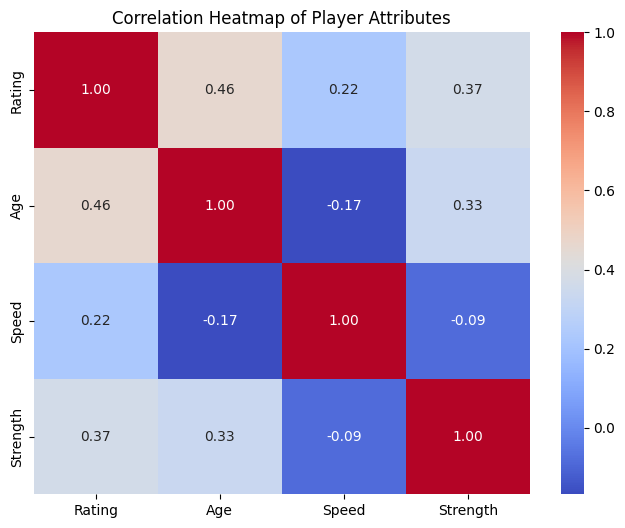

In [76]:
# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Player Attributes")
plt.show()

In [77]:
# Analyze average rating by age
age_analysis = (
    df.groupby("Age")
      .agg(avg_rating=("Rating", "mean"))
      .reset_index()
      .sort_values("Age")
)

age_analysis.head()

,Age,avg_rating
0,17,55.477707
1,18,56.769231
2,19,58.572709
3,20,60.660033
4,21,62.990803


In [78]:
speed_rating_stats = df[["Speed", "Rating"]].describe()
speed_rating_stats

,Speed,Rating
count,17583.000000,17583.000000
mean,65.487403,66.166069
std,14.099055,7.082718
min,11.000000,45.000000
25%,58.000000,62.000000
50%,68.000000,66.000000
75%,75.000000,71.000000
max,96.000000,94.000000


### Key Insights

# Section 4

### Research Question 1: How are player ratings distributed across the dataset?

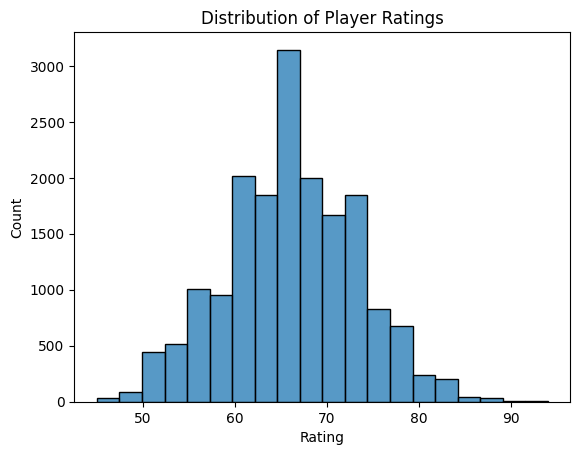

In [79]:
plt.figure()
sns.histplot(df['Rating'], bins=20)

plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

### Research Question 2: How does average player rating change with age?

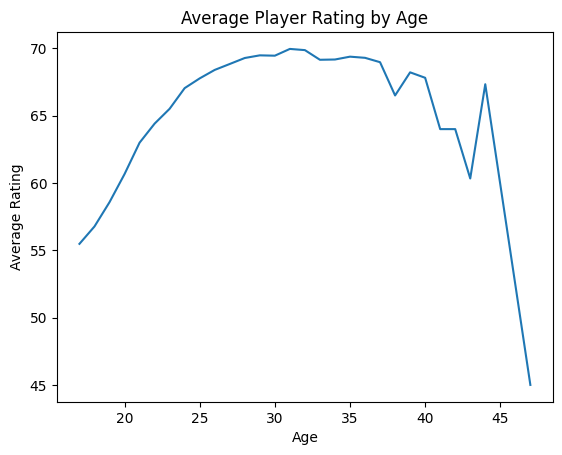

In [80]:
age_rating = df.groupby('Age')['Rating'].mean()

plt.figure()
age_rating.plot()

plt.title("Average Player Rating by Age")
plt.xlabel("Age")
plt.ylabel("Average Rating")

plt.show()

### Research Question 3: Is there a relationship between player speed and overall rating?

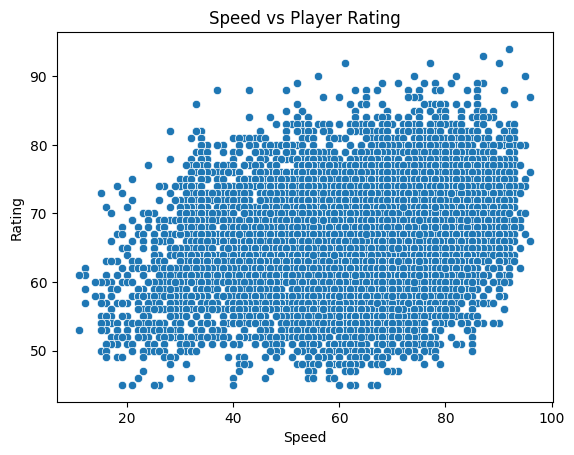

In [81]:
plt.figure()
sns.scatterplot(x='Speed', y='Rating', data=df)

plt.title("Speed vs Player Rating")
plt.xlabel("Speed")
plt.ylabel("Rating")

plt.show()